#### 0. Realizar a limpeza dos diretórios para evitar falhas de execução

In [1]:
%%bash
rm -rf ../../data/1-sot/*

#### 1. Realizar a importação dos módulos

In [2]:
from dotenv import load_dotenv
import duckdb
import matplotlib.pyplot as matplotlib
import os

#### 2. Realizar a conexão com o banco de dados Postgress

In [3]:
load_dotenv()

con = duckdb.connect()

con.execute("INSTALL postgres;")

con.execute("LOAD postgres;")

con_str = (
    f"host={os.getenv('PG_HOST')} "
    f"dbname={os.getenv('PG_DB')} "
    f"user={os.getenv('PG_USER')} "
    f"password={os.getenv('PG_PASSWORD')} "
    f"port={os.getenv('PG_PORT')}"
)

con.execute(f"""ATTACH '{con_str}' AS pg (TYPE postgres);""")

#### 3. Realizar a gravação de uma amostra de 5% dos dados de cada arquivo parquet da camada SOR

3.1. Além disso, são removidos registros que possuam ao menos um atributo sem informação (vazio ou nulo).

In [4]:
sor_files_list = os.listdir("../../data/0-sor/")
sor_files_list

for sor_file in sor_files_list:
    
    input_path = f"../../data/0-sor/{sor_file}"
    filename = os.path.basename(sor_file)
    output_path = f"../../data/1-sot/sample-{filename}"
    
    query = f"""
    COPY 
    (
        SELECT 
            *
        FROM 
            read_parquet("{input_path}", union_by_name=true)
        WHERE 
            hash(request_datetime) % 100 < 5
    )
    TO "{output_path}" (FORMAT "parquet", COMPRESSION "snappy");
    """
    
    con.execute(query)

#### 4. Realizar a gravação de um arquivo unificado considerando todas as amostras geradas

In [ ]:
input_path = "../../data/1-sot/*.parquet"
output_path = "../../data/1-sot/unified-tb-sor-fhvhv-trip-data.parquet"

query = f"""
COPY 
(
    SELECT 
        *
    FROM 
        read_parquet("{input_path}")
)
TO "{output_path}" (FORMAT "parquet", COMPRESSION "snappy");
"""

con.execute(query)

#### 5. Realizar a exclusão dos arquivos das amostras não unificadas

In [6]:
%%bash
rm -f ../../data/1-sot/sample*

#### 6. Realizar a leitura da base unificada e padronizar o nome das colunas e dos tipos de dados

6.1. Além disso, filtram-se somente as viagens que aconteceram a partir de 01/01/2025.

In [7]:
input_path = "../../data/1-sot/unified-tb-sor-fhvhv-trip-data.parquet"

sot = duckdb.sql(f"""
    SELECT 
        UPPER(TRIM(CAST(hvfhs_license_num AS VARCHAR))) AS identificador_empresa,
        UPPER(TRIM(CAST(dispatching_base_num AS VARCHAR))) AS identificador_base_despacho,
        UPPER(TRIM(CAST(originating_base_num AS VARCHAR))) AS identificador_base_origem,
        
        SUBSTRING(CAST(request_datetime AS VARCHAR), 1, 7) AS anomes_solicitacao,
        CAST(request_datetime AS DATE) AS data_solicitacao,
        CASE 
            WHEN STRFTIME(request_datetime, '%A') = 'Sunday' THEN 'a. Domingo' 
            WHEN STRFTIME(request_datetime, '%A') = 'Monday' THEN 'b. Segunda-feira' 
            WHEN STRFTIME(request_datetime, '%A') = 'Tuesday' THEN 'c. Terça-feira' 
            WHEN STRFTIME(request_datetime, '%A') = 'Wednesday' THEN 'd. Quarta-feira' 
            WHEN STRFTIME(request_datetime, '%A') = 'Thursday' THEN 'e. Quinta-feira' 
            WHEN STRFTIME(request_datetime, '%A') = 'Friday' THEN 'f. Sexta-feira' 
            WHEN STRFTIME(request_datetime, '%A') = 'Saturday' THEN 'g. Sábado' 
        END AS nome_dia_semana_solicitacao,
        CAST(request_datetime AS TIME) AS hora_solicitacao,
        CASE 
            WHEN EXTRACT(hour FROM CAST(request_datetime AS TIME)) BETWEEN 0 AND 6 THEN 'a. Madrugada'
            WHEN EXTRACT(hour FROM CAST(request_datetime AS TIME)) BETWEEN 7 AND 12 THEN 'b. Manhã'
            WHEN EXTRACT(hour FROM CAST(request_datetime AS TIME)) BETWEEN 13 AND 18 THEN 'c. Tarde'
            WHEN EXTRACT(hour FROM CAST(request_datetime AS TIME)) BETWEEN 19 AND 23 THEN 'd. Noite'
        END AS nome_periodo_solicitacao,
        
        SUBSTRING(CAST(on_scene_datetime AS VARCHAR), 1, 7) AS anomes_chegada_motorista,
        CAST(on_scene_datetime AS DATE) AS data_chegada_motorista,
        CASE 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Sunday' THEN 'a. Domingo' 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Monday' THEN 'b. Segunda-feira' 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Tuesday' THEN 'c. Terça-feira' 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Wednesday' THEN 'd. Quarta-feira' 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Thursday' THEN 'e. Quinta-feira' 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Friday' THEN 'f. Sexta-feira' 
            WHEN STRFTIME(on_scene_datetime, '%A') = 'Saturday' THEN 'g. Sábado' 
        END AS nome_dia_semana_chegada,
        CAST(on_scene_datetime AS TIME) AS hora_chegada_motorista,
        CASE 
            WHEN EXTRACT(hour FROM CAST(on_scene_datetime AS TIME)) BETWEEN 0 AND 6 THEN 'a. Madrugada'
            WHEN EXTRACT(hour FROM CAST(on_scene_datetime AS TIME)) BETWEEN 7 AND 12 THEN 'b. Manhã'
            WHEN EXTRACT(hour FROM CAST(on_scene_datetime AS TIME)) BETWEEN 13 AND 18 THEN 'c. Tarde'
            WHEN EXTRACT(hour FROM CAST(on_scene_datetime AS TIME)) BETWEEN 19 AND 23 THEN 'd. Noite'
        END AS nome_periodo_chegada_motorista,
        
        SUBSTRING(CAST(pickup_datetime AS VARCHAR), 1, 7) AS anomes_inicio_viagem,
        CAST(pickup_datetime AS DATE) AS data_inicio_viagem,
        CASE 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Sunday' THEN 'a. Domingo' 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Monday' THEN 'b. Segunda-feira' 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Tuesday' THEN 'c. Terça-feira' 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Wednesday' THEN 'd. Quarta-feira' 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Thursday' THEN 'e. Quinta-feira' 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Friday' THEN 'f. Sexta-feira' 
            WHEN STRFTIME(pickup_datetime, '%A') = 'Saturday' THEN 'g. Sábado' 
        END AS nome_dia_semana_inicio_viagem,
        CAST(pickup_datetime AS TIME) AS hora_inicio_viagem,
        CASE 
            WHEN EXTRACT(hour FROM CAST(pickup_datetime AS TIME)) BETWEEN 0 AND 6 THEN 'a. Madrugada'
            WHEN EXTRACT(hour FROM CAST(pickup_datetime AS TIME)) BETWEEN 7 AND 12 THEN 'b. Manhã'
            WHEN EXTRACT(hour FROM CAST(pickup_datetime AS TIME)) BETWEEN 13 AND 18 THEN 'c. Tarde'
            WHEN EXTRACT(hour FROM CAST(pickup_datetime AS TIME)) BETWEEN 19 AND 23 THEN 'd. Noite'
        END AS nome_periodo_inicio_viagem,
        DATE_DIFF('second', CAST(on_scene_datetime AS TIME), CAST(dropoff_datetime AS TIME)) AS diferenca_chegada_motorista_fim_viagem,
        SUBSTRING(CAST(dropoff_datetime AS VARCHAR), 1, 7) AS anomes_fim_viagem,
        CAST(dropoff_datetime AS DATE) AS data_fim_viagem,
        CASE 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Sunday' THEN 'a. Domingo' 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Monday' THEN 'b. Segunda-feira' 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Tuesday' THEN 'c. Terça-feira' 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Wednesday' THEN 'd. Quarta-feira' 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Thursday' THEN 'e. Quinta-feira' 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Friday' THEN 'f. Sexta-feira' 
            WHEN STRFTIME(dropoff_datetime, '%A') = 'Saturday' THEN 'g. Sábado' 
        END AS nome_dia_semana_fim_viagem,
        CAST(dropoff_datetime AS TIME) AS hora_fim_viagem,
        CASE 
            WHEN EXTRACT(hour FROM CAST(dropoff_datetime AS TIME)) BETWEEN 0 AND 6 THEN 'a. Madrugada'
            WHEN EXTRACT(hour FROM CAST(dropoff_datetime AS TIME)) BETWEEN 7 AND 12 THEN 'b. Manhã'
            WHEN EXTRACT(hour FROM CAST(dropoff_datetime AS TIME)) BETWEEN 13 AND 18 THEN 'c. Tarde'
            WHEN EXTRACT(hour FROM CAST(dropoff_datetime AS TIME)) BETWEEN 19 AND 23 THEN 'd. Noite'
        END AS nome_periodo_fim_viagem,
        DATE_DIFF('second', CAST(pickup_datetime AS TIME), CAST(dropoff_datetime AS TIME)) AS diferenca_inicio_viagem_fim_viagem,
        CAST(PULocationID AS DECIMAL(16,2)) AS identificador_localizacao_embarque,
        CAST(DOLocationID AS DECIMAL(16,2)) AS identificador_localizacao_desembarque,
        CAST(trip_miles AS DECIMAL(16,2)) AS quantidade_milhas_viagem,
        CAST(trip_time AS DECIMAL(16,2)) AS quantidade_segundos_viagem,
        CAST(trip_miles AS DECIMAL(16,2)) / (CAST(trip_time AS DECIMAL(16,2)) / 3600) as valor_velocidade_media_viagem,
        CAST(base_passenger_fare AS DECIMAL(16,2)) AS valor_tarifa_base_passageiro,
        CAST(tolls AS DECIMAL(16,2)) AS valor_pedagios,
        CAST(bcf AS DECIMAL(16,2)) AS valor_fundo_black_car,
        CAST(sales_tax AS DECIMAL(16,2)) AS valor_imposto_vendas,
        CAST(congestion_surcharge AS DECIMAL(16,2)) AS valor_taxa_congestionamento,
        CAST(airport_fee AS DECIMAL(16,2)) AS valor_taxa_aeroporto,
        CAST(tips AS DECIMAL(16,2)) AS valor_gorjeta,
        CAST(driver_pay AS DECIMAL(16,2)) AS valor_pagamento_motorista,
        COALESCE(CAST(base_passenger_fare AS DECIMAL(16,2)), 0) + COALESCE(CAST(tolls AS DECIMAL(16,2)), 0) + COALESCE(CAST(bcf AS DECIMAL(16,2)), 0) + COALESCE(CAST(sales_tax AS DECIMAL(16,2)), 0) + COALESCE(CAST(congestion_surcharge AS DECIMAL(16,2)), 0) + COALESCE(CAST(airport_fee AS DECIMAL(16,2)), 0) + COALESCE(CAST(cbd_congestion_fee AS DECIMAL(16,2)), 0) + COALESCE(CAST(tips AS DECIMAL(16,2)), 0) AS valor_receita_total_viagem,
        CAST(shared_request_flag AS VARCHAR) AS indicador_corrida_compartilhada_solicitada,
        CAST(shared_match_flag AS VARCHAR) AS indicador_corrida_compartilhada_realizada,
        CAST(access_a_ride_flag AS VARCHAR) AS indicador_corrida_mta,
        CAST(wav_request_flag AS VARCHAR) AS indicador_veiculo_acessivel_solicitado,
        CAST(wav_match_flag AS VARCHAR) AS indicador_veiculo_acessivel_realizado,
        CAST(cbd_congestion_fee AS DECIMAL(16,2)) AS valor_taxa_congestionamento_cb
    FROM 
        read_parquet('{input_path}')
    WHERE
        SUBSTRING(CAST(request_datetime AS VARCHAR), 1, 7) >= '2025-01'
""").df()

sot.head(5)

,identificador_empresa,identificador_base_despacho,identificador_base_origem,anomes_solicitacao,data_solicitacao,nome_dia_semana_solicitacao,hora_solicitacao,nome_periodo_solicitacao,anomes_chegada_motorista,data_chegada_motorista,...,valor_taxa_aeroporto,valor_gorjeta,valor_pagamento_motorista,valor_receita_total_viagem,indicador_corrida_compartilhada_solicitada,indicador_corrida_compartilhada_realizada,indicador_corrida_mta,indicador_veiculo_acessivel_solicitado,indicador_veiculo_acessivel_realizado,valor_taxa_congestionamento_cb
0,HV0003,B03404,B03404,2025-01,2025-01-01,d. Quarta-feira,00:01:45,a. Madrugada,2025-01,2025-01-01,...,0.0,0.0,29.30,28.97,N,N,N,N,N,0.0
1,HV0003,B03404,B03404,2025-01,2025-01-01,d. Quarta-feira,00:11:04,a. Madrugada,2025-01,2025-01-01,...,0.0,0.0,14.47,24.92,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2025-01,2025-01-01,d. Quarta-feira,00:37:35,a. Madrugada,2025-01,2025-01-01,...,0.0,0.0,11.99,23.86,N,N,N,N,N,0.0
3,HV0003,B03404,B03404,2025-01,2025-01-01,d. Quarta-feira,00:33:02,a. Madrugada,2025-01,2025-01-01,...,0.0,0.0,10.18,14.98,N,N,N,N,N,0.0
4,HV0003,B03404,B03404,2025-01,2025-01-01,d. Quarta-feira,00:19:13,a. Madrugada,2025-01,2025-01-01,...,0.0,0.0,6.54,12.59,N,N,N,N,N,0.0


#### 7. Realizar a análise exploratória dos dados

7.1. Principais métricas

In [8]:
sot.describe()

,data_solicitacao,data_chegada_motorista,data_inicio_viagem,diferenca_chegada_motorista_fim_viagem,data_fim_viagem,diferenca_inicio_viagem_fim_viagem,identificador_localizacao_embarque,identificador_localizacao_desembarque,quantidade_milhas_viagem,quantidade_segundos_viagem,...,valor_tarifa_base_passageiro,valor_pedagios,valor_fundo_black_car,valor_imposto_vendas,valor_taxa_congestionamento,valor_taxa_aeroporto,valor_gorjeta,valor_pagamento_motorista,valor_receita_total_viagem,valor_taxa_congestionamento_cb
count,12201354,11658390,12201354,11658390.0,12201354,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,...,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07,1.220135e+07
mean,2025-07-02 23:11:29.457449,2025-07-09 23:39:35.485122,2025-07-02 23:16:45.525977,42.738502,2025-07-02 23:35:56.444540,4.180120e+01,1.382914e+02,1.421867e+02,5.032672e+00,1.192792e+03,...,2.694399e+01,1.100877e+00,6.777707e-01,2.239757e+00,9.865477e-01,2.137201e-01,1.194675e+00,2.081687e+01,3.386725e+01,5.099109e-01
min,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,-86353.0,2025-01-01 00:00:00,-8.636900e+04,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,...,-1.031100e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-3.699000e+01,-4.000000e+01,0.000000e+00
25%,2025-04-02 00:00:00,2025-04-13 00:00:00,2025-04-02 00:00:00,626.0,2025-04-02 00:00:00,5.780000e+02,7.500000e+01,7.600000e+01,1.540000e+00,5.950000e+02,...,1.248000e+01,0.000000e+00,3.000000e-01,1.020000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.160000e+00,1.499000e+01,0.000000e+00
50%,2025-07-02 00:00:00,2025-07-11 00:00:00,2025-07-02 00:00:00,1006.0,2025-07-02 00:00:00,9.520000e+02,1.380000e+02,1.410000e+02,2.980000e+00,9.680000e+02,...,1.955000e+01,0.000000e+00,4.800000e-01,1.640000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.553000e+01,2.399000e+01,0.000000e+00
75%,2025-10-05 00:00:00,2025-10-09 00:00:00,2025-10-05 00:00:00,1584.0,2025-10-05 00:00:00,1.518000e+03,2.090000e+02,2.160000e+02,6.310000e+00,1.537000e+03,...,3.223000e+01,0.000000e+00,8.100000e-01,2.740000e+00,2.750000e+00,0.000000e+00,0.000000e+00,2.631000e+01,4.088000e+01,1.500000e+00
max,2025-12-31 00:00:00,2025-12-31 00:00:00,2025-12-31 00:00:00,33791.0,2026-01-01 00:00:00,3.376200e+04,2.650000e+02,2.650000e+02,4.296300e+02,4.284900e+04,...,1.657280e+03,1.057600e+02,4.140000e+01,1.523900e+02,5.500000e+00,7.500000e+00,1.994000e+02,1.461100e+03,1.915200e+03,3.000000e+00
std,NaN,NaN,NaN,10140.081755,NaN,9.889598e+03,7.484739e+01,7.812243e+01,5.899223e+00,8.604904e+02,...,2.466897e+01,3.598798e+00,6.432551e-01,2.027902e+00,1.314585e+00,7.028628e-01,3.596380e+00,1.817845e+01,3.128618e+01,7.105349e-01


7.2. Volume de viagens solicitadas por mês

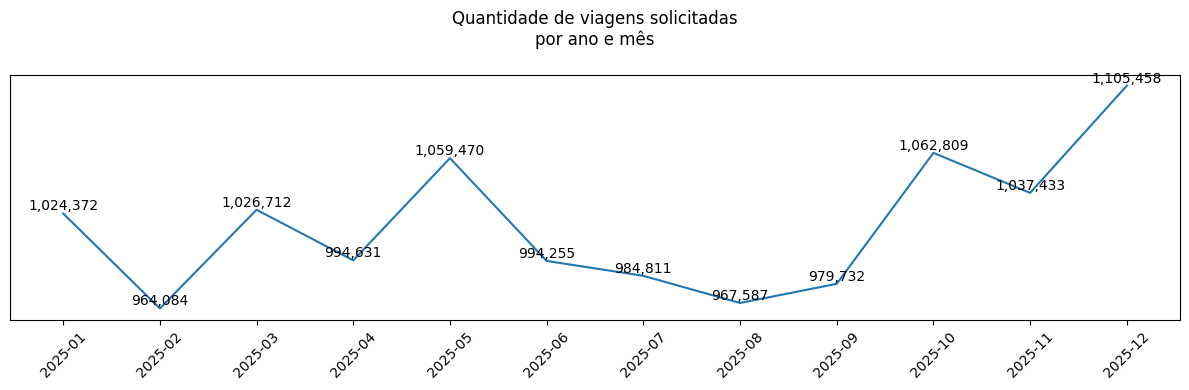

In [9]:
graph_1_travels_per_day = (
    sot
    .groupby(sot["anomes_solicitacao"])
    .size()
    .reset_index(name="quantidade_solicitacoes")
)

matplotlib.figure(figsize=(12, 4))

x = graph_1_travels_per_day["anomes_solicitacao"]
y = graph_1_travels_per_day["quantidade_solicitacoes"]

matplotlib.plot(x, y)

matplotlib.title("Quantidade de viagens solicitadas\npor ano e mês\n")

matplotlib.xticks(rotation=45)

matplotlib.gca().yaxis.set_visible(False)

for i, value in enumerate(y):
    matplotlib.text(x[i], value, f"{value:,}", ha='center', va='bottom')

matplotlib.tight_layout()

matplotlib.show()

7.3. Volume de viagens solicitadas por dia da semana

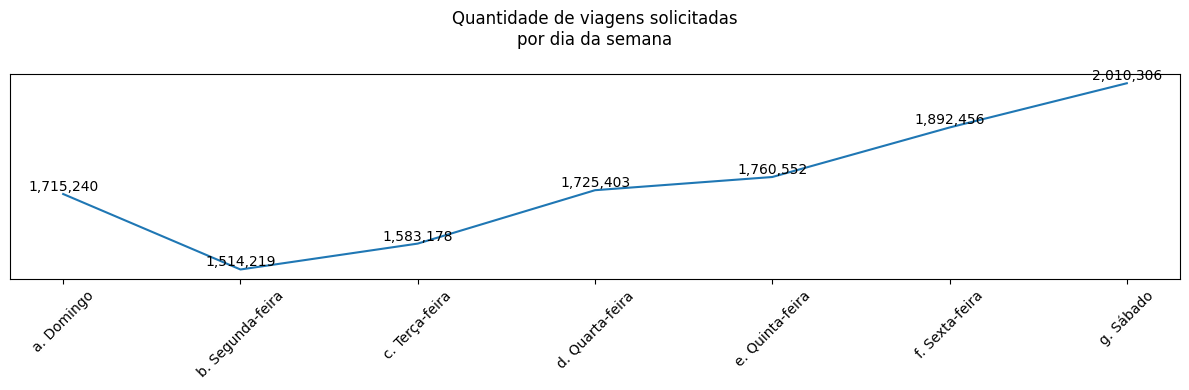

In [10]:
graph_2_travels_per_weekday = (
    sot
    .groupby(sot["nome_dia_semana_solicitacao"])
    .size()
    .reset_index(name="quantidade_solicitacoes")
)

matplotlib.figure(figsize=(12, 4))

x = graph_2_travels_per_weekday["nome_dia_semana_solicitacao"]
y = graph_2_travels_per_weekday["quantidade_solicitacoes"]

matplotlib.plot(x, y)

matplotlib.title("Quantidade de viagens solicitadas\npor dia da semana\n")

matplotlib.xticks(rotation=45)

matplotlib.gca().yaxis.set_visible(False)

for i, value in enumerate(y):
    matplotlib.text(x[i], value, f"{value:,}", ha='center', va='bottom')

matplotlib.tight_layout()

matplotlib.show()

7.4. Velocidade média das viagens realizadas

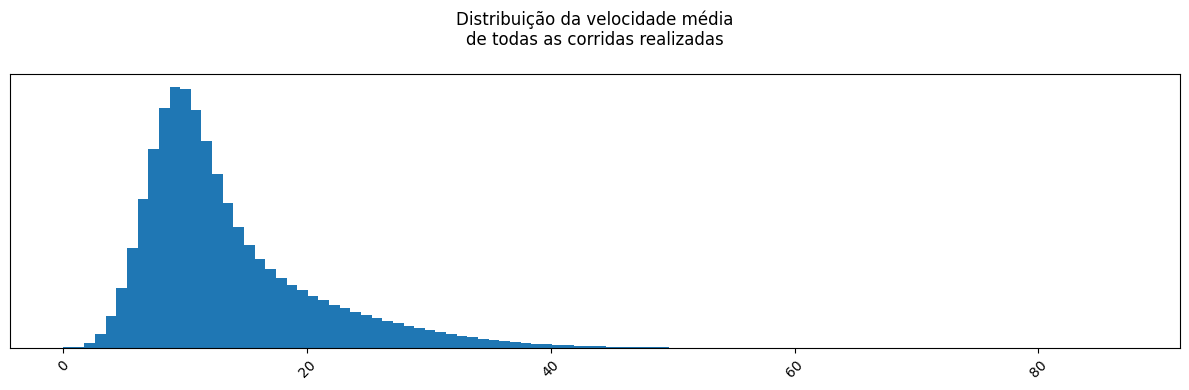

In [11]:
matplotlib.figure(figsize=(12, 4))

matplotlib.hist(sot["valor_velocidade_media_viagem"].dropna(), bins=100)

matplotlib.title("Distribuição da velocidade média\nde todas as corridas realizadas\n")

matplotlib.xticks(rotation=45)

matplotlib.gca().yaxis.set_visible(False)

matplotlib.tight_layout()

matplotlib.show()

7.5. Receita das corridas realizadas

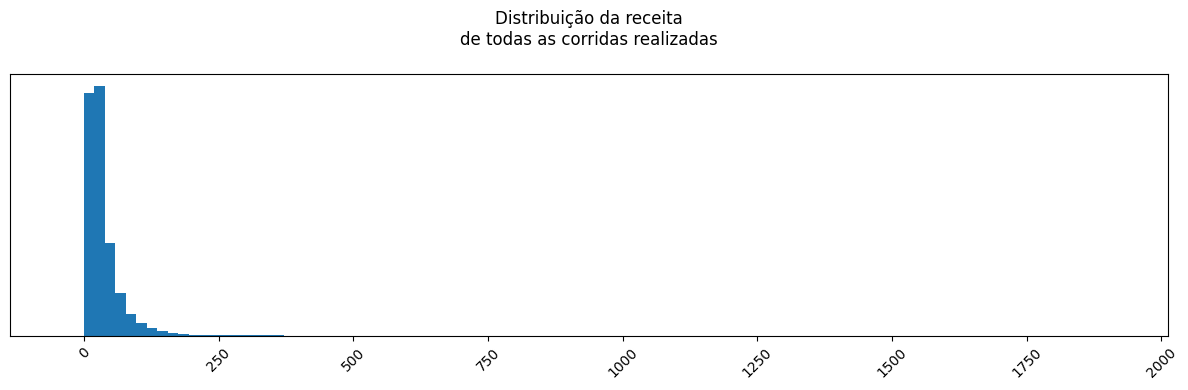

In [12]:
matplotlib.figure(figsize=(12, 4))

matplotlib.hist(sot["valor_receita_total_viagem"].dropna(), bins=100)

matplotlib.title("Distribuição da receita\nde todas as corridas realizadas\n")

matplotlib.xticks(rotation=45)

matplotlib.gca().yaxis.set_visible(False)

matplotlib.tight_layout()

matplotlib.show()

7.6. Relação entre as variáveis "distância" e "receita" das viagens

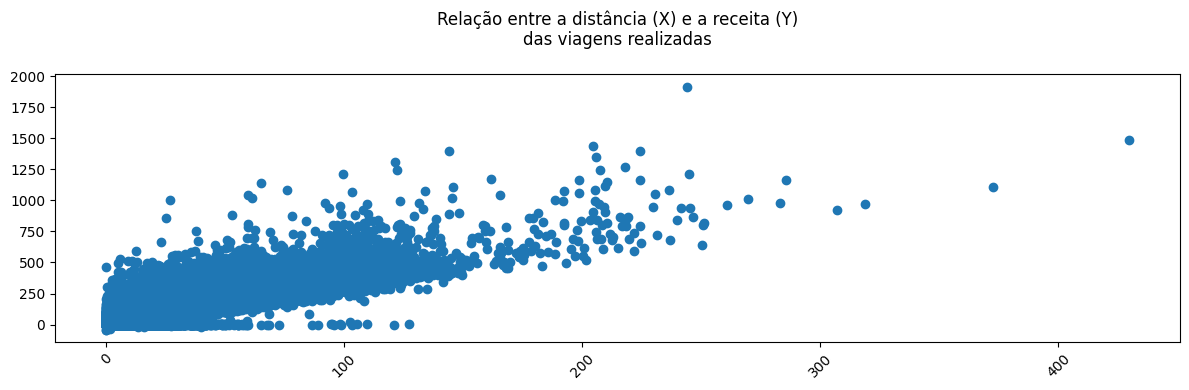

In [13]:
matplotlib.figure(figsize=(12, 4))

matplotlib.scatter(sot["quantidade_milhas_viagem"], sot["valor_receita_total_viagem"])

matplotlib.title("Relação entre a distância (X) e a receita (Y)\ndas viagens realizadas\n")

matplotlib.xticks(rotation=45)

matplotlib.tight_layout()

matplotlib.show()

#### 8. Realizar a gravação do arquivo parquet da camada SOT

In [14]:
output_path = f"../../data/1-sot/tb-sot-fhvhv-trip-data-unified.parquet"

query = f"""
COPY 
(
    SELECT 
        *
    FROM 
        sot
)
TO "{output_path}" (FORMAT "parquet", COMPRESSION "snappy");
"""
    
con.execute(query)

#### 9. Realizar a exclusão dos arquivos intermediários

In [15]:
%%bash
rm -f ../../data/1-sot/unified*

#### 10. Realizar o encerramento da sessão com o banco de dados

In [16]:
con.close()